In [1]:
import numpy as np
import pandas as pd

models = [
    "GPT-2",
    "DistilGPT-2",
    "GPT-Neo",
    "DialoGPT",
    "Bloom"
]

data = pd.DataFrame({
    "Model": models,
    "Quality": [85, 80, 88, 82, 86],        # higher better
    "Inference_Time": [120, 90, 150, 110, 140],  # lower better
    "Model_Size": [500, 300, 1200, 400, 1500]    # lower better
})

matrix = data.iloc[:, 1:].values.astype(float)

norm = matrix / np.sqrt((matrix**2).sum(axis=0))

weights = np.array([0.5, 0.3, 0.2])   # you can slightly change

weighted = norm * weights

# For benefit criteria (Quality) → max
# For cost criteria → min

ideal_best = np.array([
    weighted[:,0].max(),    # Q
    weighted[:,1].min(),    # T
    weighted[:,2].min()     # S
])

ideal_worst = np.array([
    weighted[:,0].min(),
    weighted[:,1].max(),
    weighted[:,2].max()
])

dist_best = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

score = dist_worst / (dist_best + dist_worst)

data["TOPSIS Score"] = score

data["Rank"] = data["TOPSIS Score"].rank(ascending=False)

print(data.sort_values(by="Rank"))

         Model  Quality  Inference_Time  Model_Size  TOPSIS Score  Rank
1  DistilGPT-2       80              90         300      0.863268   1.0
3     DialoGPT       82             110         400      0.802173   2.0
0        GPT-2       85             120         500      0.728221   3.0
2      GPT-Neo       88             150        1200      0.248686   4.0
4        Bloom       86             140        1500      0.129676   5.0


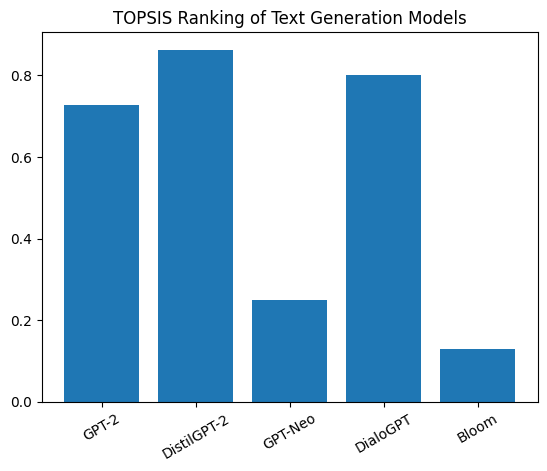

In [2]:
import matplotlib.pyplot as plt

plt.bar(data["Model"], data["TOPSIS Score"])
plt.xticks(rotation=30)
plt.title("TOPSIS Ranking of Text Generation Models")
plt.show()